# Lumped 0D Transient Heat Balance for Gold

This notebook calculates the temperature rise from the lumped governing equation:

$$
m C_P \frac{dT}{dt}
+ 4\pi R^2 \varepsilon \sigma \left(T^4 - T_0^4\right)
= \frac{E_P I}{e_c}
$$

This equation assumes the gold particle has one uniform temperature, so there is no spatial diffusion term. The area term $4\pi R^2$ corresponds to a spherical particle of radius $R$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Parameters

The beam and Au parameters match the main notebook. The lumped equation uses a fixed total beam current, $I = 50\,\mathrm{nA}$.

In [2]:
# Physical constants
e_c = 1.602176634e-19
sigma_SB = 5.670374419e-8

# Beam parameters
E_beam_keV = 300.0
deposited_fraction = 0.0071
E_P_keV = E_beam_keV * deposited_fraction
E_P_J = E_P_keV * 1e3 * e_c
I_total = 50.0e-9

# Gold material properties
rho_Au = 19.32e3
Cp_Au = 129.0
eps_Au = 1.0
T0 = 300.0
T_sublimate_Au = 1275.0

# Geometry for the lumped equation as written: spherical particle, diameter 1 um
R = 0.5e-6
projected_area = np.pi * R**2
surface_area = 4.0 * np.pi * R**2
volume = (4.0 / 3.0) * np.pi * R**3
mass = rho_Au * volume

# Deposited heating power from the fixed total current
P_in = E_P_J * I_total / e_c

print(f'E_P = {E_P_keV:.4f} keV = {E_P_J:.4e} J per electron')
print(f'I_total = {I_total * 1e9:.2f} nA = {I_total:.3e} A')
print(f'P_in = E_P*I/e_c = {P_in:.3e} W')
print(f'mass = {mass:.3e} kg')
print(f'thermal capacity m Cp = {mass * Cp_Au:.3e} J/K')

E_P = 2.1300 keV = 3.4126e-16 J per electron
I_total = 50.00 nA = 5.000e-08 A
P_in = E_P*I/e_c = 1.065e-04 W
mass = 1.012e-14 kg
thermal capacity m Cp = 1.305e-12 J/K


## Solve the ODE

The solved form is:

$$
\frac{dT}{dt}
= \frac{P_{\mathrm{in}} - A \varepsilon \sigma \left(T^4 - T_0^4\right)}{m C_P}
$$

where $A = 4\pi R^2$ for the spherical-particle assumption used here.

## Physics Note

This 0D model treats the Au particle as a single thermal mass. The entire particle is assumed to have one temperature $T(t)$ at each time, so internal temperature gradients are ignored. This is a lumped-capacitance approximation:

$$
\text{thermal storage} = \text{beam heating} - \text{radiative cooling}
$$

or

$$
m C_P \frac{dT}{dt}
= P_{\mathrm{in}} - A\varepsilon\sigma\left(T^4 - T_0^4\right).
$$

The input power is calculated from the deposited energy per electron and the total beam current:

$$
P_{\mathrm{in}} = \frac{E_P I}{e_c}.
$$

Because the radiative loss term grows as $T^4$, the mathematical model has a saturation temperature where heating and radiation balance:

$$
P_{\mathrm{in}} = A\varepsilon\sigma\left(T_{\mathrm{eq}}^4 - T_0^4\right),
$$

so

$$
T_{\mathrm{eq}}
= \left(T_0^4 + \frac{P_{\mathrm{in}}}{A\varepsilon\sigma}\right)^{1/4}.
$$

For the current settings, this radiative equilibrium is very high. The curve approaches this value only after a longer time window, which is why a nanosecond-scale plot looked almost horizontal.

Important limitation: once the calculated temperature reaches the melting or sublimation range, the simple solid-particle model is no longer physically complete. A more realistic model would include temperature-dependent material properties, melting, latent heat, evaporation or mass loss, possible shape changes, and nonuniform temperature inside the particle. Therefore, the equilibrium line is best understood as the saturation of this simplified radiation-only 0D model, not necessarily the real final temperature of the Au particle.

In [3]:
def dTdt(t, T):
    T_scalar = T[0]
    P_rad = surface_area * eps_Au * sigma_SB * (T_scalar**4 - T0**4)
    return [(P_in - P_rad) / (mass * Cp_Au)]

# Radiation gives a mathematical saturation temperature when P_in = A*eps*sigma*(T_eq^4 - T0^4).
T_equilibrium = (T0**4 + P_in / (surface_area * eps_Au * sigma_SB))**0.25

# Extend the simulation long enough to show the approach toward that saturation value.
t_end = 100.0e-6
t_eval = np.linspace(0.0, t_end, 3000)
solution = solve_ivp(dTdt, (0.0, t_end), [T0], t_eval=t_eval, method='RK45')

t = solution.t
T = solution.y[0]

above_sublimation = np.flatnonzero(T >= T_sublimate_Au)
t_sublimation = t[above_sublimation[0]] if above_sublimation.size else None

print(f't_end = {t_end * 1e6:.2f} us')
print(f'T_equilibrium = {T_equilibrium:.2f} K')
print(f'T(t_end) = {T[-1]:.2f} K')
print(f'T_max = {T.max():.2f} K')
print(f'T_sublimate = {T_sublimate_Au:.0f} K')
print(f'Delta T at t_end = {T[-1] - T0:.2f} K')
if t_sublimation is not None:
    print(f'T reaches sublimation reference at t = {t_sublimation * 1e6:.2f} us')
else:
    print('T does not reach the sublimation reference in this time window')

t_end = 100.00 us
T_equilibrium = 4944.80 K
T(t_end) = 4895.01 K
T_max = 4895.01 K
T_sublimate = 1275 K
Delta T at t_end = 4595.01 K
T reaches sublimation reference at t = 11.97 us


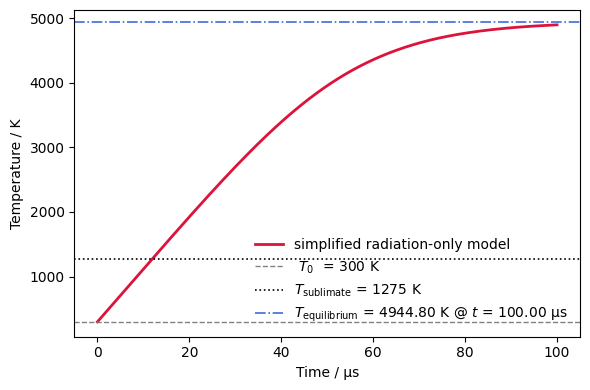

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(t * 1e6, T, color='crimson', lw=2, label='simplified radiation-only model')
plt.axhline(T0, color='0.5', ls='--', lw=1, label=f' $T_0$  = {T0:.0f} K')
plt.axhline(T_sublimate_Au, color='black', ls=':', lw=1.2, label=f'$T_\\mathrm{{sublimate}}$ = {T_sublimate_Au:.0f} K')
plt.axhline(T_equilibrium, color='royalblue', ls='-.', lw=1.2, label=f'$T_\\mathrm{{equilibrium}}$ = {T_equilibrium:.2f} K @ $t$ = {t_end * 1e6:.2f} µs')
plt.xlabel('Time / µs')
plt.ylabel('Temperature / K')
plt.legend(loc='best', frameon=False)
plt.tight_layout()
plt.savefig('T_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare 0D, 2D, and 3D Temperature Histories

This comparison uses the same beam current, deposited energy, gold sphere radius, and spherical radiative equilibrium temperature. The 0D curve is evaluated from the lumped ODE, the 2D curve is recomputed from `Scorer_1.csv`, and the 3D curve is read from the exported `T3D_csv/T3D_histories.csv` file.


In [6]:
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

# Shared uniform radiation-balance equilibrium for the spherical particle.
T_equilibrium_shared = (T0**4 + P_in / (surface_area * eps_Au * sigma_SB))**0.25

# 0D short-time values for direct comparison with PDE time windows.
t_short_ns = np.linspace(0.0, 3.0, 600)
t_short_s = t_short_ns * 1e-9
solution_short = solve_ivp(dTdt, (0.0, t_short_s[-1]), [T0], t_eval=t_short_s, method='RK45')
T_lumped_short = solution_short.y[0]

# Recompute the 2D PDE history using the same Scorer_1.csv source normalization.
Nx2, Ny2 = 100, 100
Lx2 = Ly2 = 1.0e-6
dx2 = Lx2 / (Nx2 - 1)
dy2 = Ly2 / (Ny2 - 1)
x2 = np.linspace(0.0, Lx2, Nx2)
y2 = np.linspace(0.0, Ly2, Ny2)
X2, Y2 = np.meshgrid(x2, y2, indexing='ij')
xc2 = Lx2 / 2.0
yc2 = Ly2 / 2.0
R_sphere2 = Lx2 / 2.0
r2 = np.sqrt((X2 - xc2)**2 + (Y2 - yc2)**2)
disk_mask2 = r2 <= R_sphere2

scorer2 = pd.read_csv('Scorer_1.csv', usecols=['X', 'Y', 'Edep'])
center_index2 = int(round(scorer2['Y'].median()))
source_x2 = np.sort(scorer2['X'].unique()) / 199.0 * Lx2
source_y2 = (np.sort(scorer2['Y'].unique()) - center_index2) / 200.0 * Ly2
source_values2 = (
    scorer2.sort_values(['X', 'Y'])['Edep']
    .to_numpy(dtype=float)
    .reshape(len(source_x2), len(source_y2))
)
source_interp2 = RegularGridInterpolator(
    (source_x2, source_y2),
    source_values2,
    bounds_error=False,
    fill_value=0.0,
)
raw_source2 = source_interp2(
    np.column_stack([X2.ravel(), (Y2 - yc2).ravel()])
).reshape(Nx2, Ny2)
raw_source2 = np.where(disk_mask2, raw_source2, 0.0)
mean_source2 = raw_source2[disk_mask2].mean()
if mean_source2 <= 0.0:
    raise ValueError('Scorer_1.csv source has zero mean inside the disk')

Q_sphere_mean2 = P_in / volume
Q2D = np.where(disk_mask2, Q_sphere_mean2 * raw_source2 / mean_source2, 0.0)
rad_coeff2 = eps_Au * sigma_SB * surface_area / volume

alpha_Au = 317.0 / (rho_Au * Cp_Au)
dt_crit2 = min(dx2, dy2)**2 / (4.0 * alpha_Au)
dt2 = 0.4 * dt_crit2
t_end2 = 1.5e-9
n_steps2 = int(np.ceil(t_end2 / dt2))
dt2 = t_end2 / n_steps2
sample_every2 = max(1, n_steps2 // 1000)

T2 = np.full((Nx2, Ny2), T0, dtype=np.float64)
Tp2 = np.empty((Nx2 + 2, Ny2 + 2))
ic2, jc2 = Nx2 // 2, Ny2 // 2
t2_hist = []
Tc2_hist = []
Tmax2_hist = []
for n in range(n_steps2 + 1):
    if n % sample_every2 == 0 or n == n_steps2:
        t2_hist.append(n * dt2)
        Tc2_hist.append(T2[ic2, jc2])
        Tmax2_hist.append(T2[disk_mask2].max())
    if n == n_steps2:
        break
    Tp2[1:-1, 1:-1] = T2
    Tp2[0, 1:-1] = T2[0, :]
    Tp2[-1, 1:-1] = T2[-1, :]
    Tp2[1:-1, 0] = T2[:, 0]
    Tp2[1:-1, -1] = T2[:, -1]
    lap2 = ((Tp2[2:, 1:-1] - 2.0 * T2 + Tp2[:-2, 1:-1]) / dx2**2 +
            (Tp2[1:-1, 2:] - 2.0 * T2 + Tp2[1:-1, :-2]) / dy2**2)
    rad2 = np.where(disk_mask2, rad_coeff2 * (T2**4 - T0**4), 0.0)
    T2 += dt2 * (317.0 * lap2 - rad2 + Q2D) / (rho_Au * Cp_Au)
    T2[~disk_mask2] = T0

t2_hist = np.asarray(t2_hist)
Tc2_hist = np.asarray(Tc2_hist)
Tmax2_hist = np.asarray(Tmax2_hist)

# Load the exported 3D history if available.
hist3d_path = 'T3D_csv/T3D_histories.csv'
hist3d = pd.read_csv(hist3d_path)
t3_ns = hist3d['t_ns'].to_numpy(dtype=float)
Tc3 = hist3d['T_centre_K'].to_numpy(dtype=float)
Tmax3 = hist3d['T_max_K'].to_numpy(dtype=float)

print(f'Uniform radiation-balance T_equilibrium = {T_equilibrium_shared:.2f} K')
print(f'P_dep = {P_in:.3e} W at I_total = {I_total * 1e9:.2f} nA')
print(f'0D T at 1.5 ns = {np.interp(1.5, t_short_ns, T_lumped_short):.4f} K')
print(f'0D T at 3.0 ns = {T_lumped_short[-1]:.4f} K')
print(f'2D T_center at 1.5 ns = {Tc2_hist[-1]:.4f} K; T_max = {Tmax2_hist[-1]:.4f} K')
print(f'3D T_center at {t3_ns[-1]:.2f} ns = {Tc3[-1]:.4f} K; T_max = {Tmax3[-1]:.4f} K')


Uniform radiation-balance T_equilibrium = 4944.80 K
P_dep = 1.065e-04 W at I_total = 50.00 nA
0D T at 1.5 ns = 300.1224 K
0D T at 3.0 ns = 300.2448 K
2D T_center at 1.5 ns = 300.0707 K; T_max = 300.0718 K
3D T_center at 3.00 ns = 300.0829 K; T_max = 300.0847 K


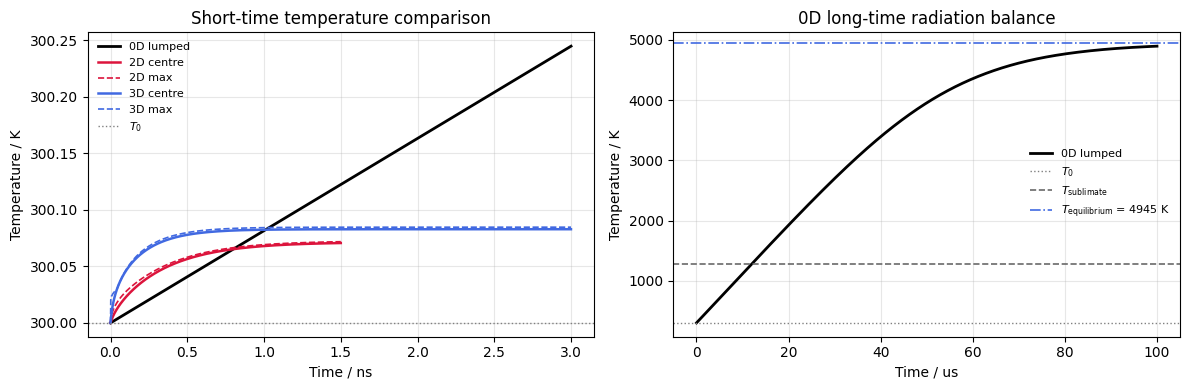

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Short-time comparison on the nanosecond scale.
axes[0].plot(t_short_ns, T_lumped_short, color='black', lw=2, label='0D lumped')
axes[0].plot(t2_hist * 1e9, Tc2_hist, color='crimson', lw=1.8, label='2D centre')
axes[0].plot(t2_hist * 1e9, Tmax2_hist, color='crimson', lw=1.2, ls='--', label='2D max')
axes[0].plot(t3_ns, Tc3, color='royalblue', lw=1.8, label='3D centre')
axes[0].plot(t3_ns, Tmax3, color='royalblue', lw=1.2, ls='--', label='3D max')
axes[0].axhline(T0, color='0.5', ls=':', lw=1, label='$T_0$')
axes[0].set_xlabel('Time / ns')
axes[0].set_ylabel('Temperature / K')
axes[0].set_title('Short-time temperature comparison')
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False, fontsize=8)

# Lumped long-time approach to the radiation-balance equilibrium.
axes[1].plot(t * 1e6, T, color='black', lw=2, label='0D lumped')
axes[1].axhline(T0, color='0.5', ls=':', lw=1, label='$T_0$')
axes[1].axhline(T_sublimate_Au, color='dimgray', ls='--', lw=1.2, label='$T_\\mathrm{sublimate}$')
axes[1].axhline(T_equilibrium_shared, color='royalblue', ls='-.', lw=1.2,
                label=f'$T_\\mathrm{{equilibrium}}$ = {T_equilibrium_shared:.0f} K')
axes[1].set_xlabel('Time / us')
axes[1].set_ylabel('Temperature / K')
axes[1].set_title('0D long-time radiation balance')
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.savefig('T_model_comparison_0d_2d_3d.png', dpi=150, bbox_inches='tight')
plt.show()
